In [19]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import folium
from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

# Set Visualization Style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"]=(10,6)



In [20]:
# load Data
df = pd.read_csv("/content/Airbnb_Open_Data.csv")
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [21]:
#Initial Inspection

print(df.shape)


(102599, 26)


In [22]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [23]:
print(df.describe())

                 id       host id            lat           long  \
count  1.025990e+05  1.025990e+05  102591.000000  102591.000000   
mean   2.914623e+07  4.925411e+10      40.728094     -73.949644   
std    1.625751e+07  2.853900e+10       0.055857       0.049521   
min    1.001254e+06  1.236005e+08      40.499790     -74.249840   
25%    1.508581e+07  2.458333e+10      40.688740     -73.982580   
50%    2.913660e+07  4.911774e+10      40.722290     -73.954440   
75%    4.320120e+07  7.399650e+10      40.762760     -73.932350   
max    5.736742e+07  9.876313e+10      40.916970     -73.705220   

       Construction year  minimum nights  number of reviews  \
count      102385.000000   102190.000000      102416.000000   
mean         2012.487464        8.135845          27.483743   
std             5.765556       30.553781          49.508954   
min          2003.000000    -1223.000000           0.000000   
25%          2007.000000        2.000000           1.000000   
50%          2012.

**Data Cleaning and preprocessing**

In [24]:
# Drop columns with All Nulls
df.drop(columns=['license'], inplace=True)


In [25]:
# Handling missing Values
# Fill categorical columns with mode or a placeholder

cat_cols = ['NAME', 'host_identity_verified', 'host name', 'neighbourhood group',
            'neighbourhood', 'country', 'country code', 'instant_bookable',
            'cancellation_policy', 'room type', 'house_rules']
for col in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0]) # used mode method




In [26]:
## Fill numerical columns with median
num_cols = ['lat', 'long', 'Construction year', 'minimum nights',
            'number of reviews', 'reviews per month', 'review rate number',
            'calculated host listings count', 'availability 365']

for col in num_cols:
    df[col]=df[col].fillna(df[col].median())

In [27]:
# Convert 'last review' to datetime
df["last review"] = pd.to_datetime(df["last review"],errors="coerce")


In [28]:
#  Clean Price & Service Fee Columns
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df['service fee'] = df['service fee'].replace('[\$,]', '', regex=True).astype(float)


In [32]:
# Remove Duplicates
df.duplicated().sum()
df.drop_duplicates(subset='id',inplace=True)


In [33]:

# Handle Outliers for Price and Minimum Nights (simple capping)
df['price'] = np.where(df['price']>10000, 10000, df['price'])
df['minimum nights'] = np.where(df['minimum nights']>365, 365, df['minimum nights'])

 **Exploratory Data Analysis & Insights**

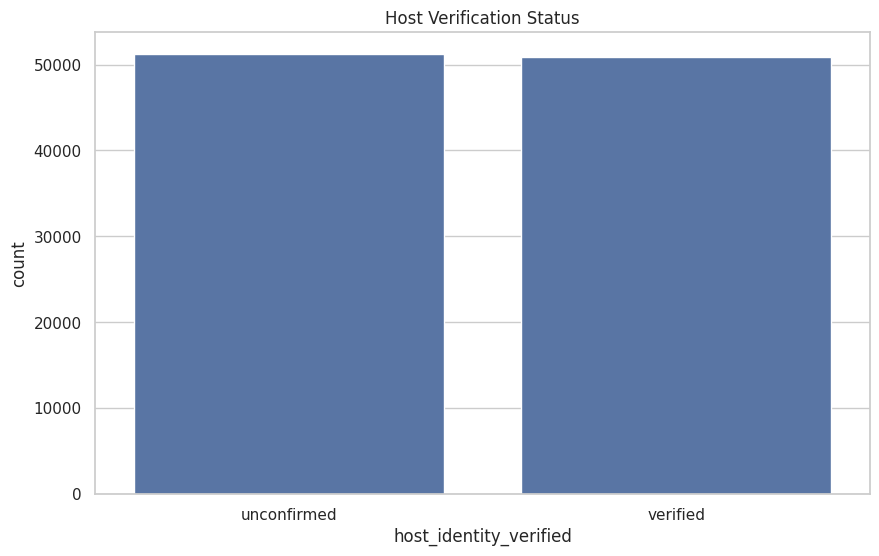

In [34]:
# -------- Host Analysis --------
# Host Verification
sns.countplot(x='host_identity_verified', data=df)
plt.title("Host Verification Status")
plt.show()

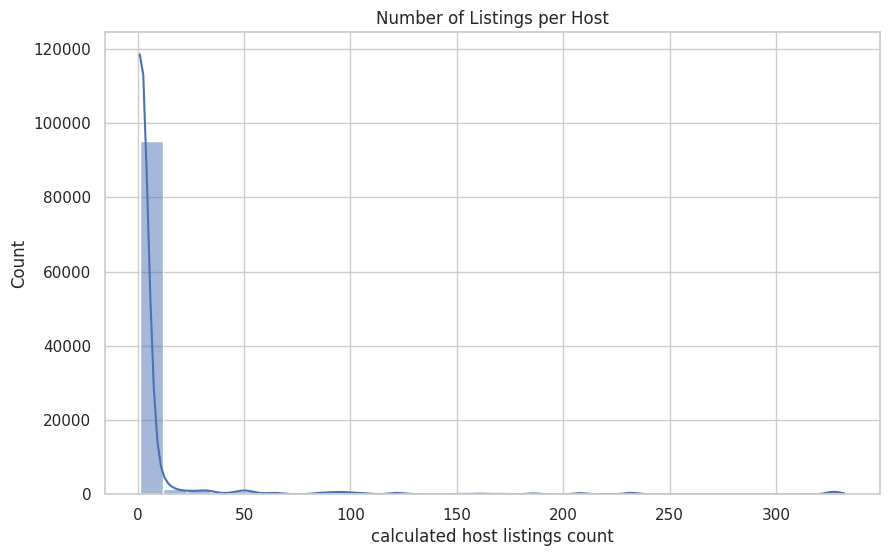

In [35]:
# Host Listings Count
sns.histplot(df['calculated host listings count'], bins=30, kde=True)
plt.title("Number of Listings per Host")
plt.show()

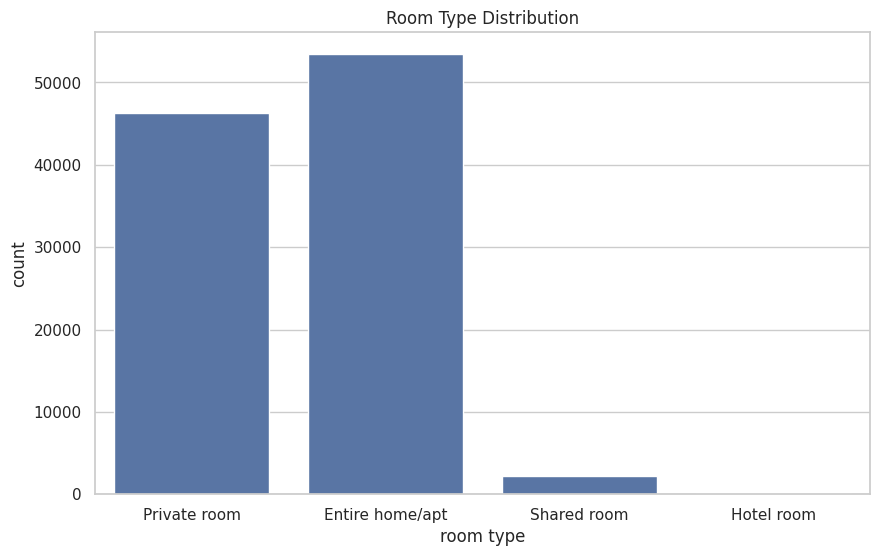

In [36]:
# -------- Room & Listing Analysis --------
# Room Type Distribution
sns.countplot(x='room type', data=df)
plt.title("Room Type Distribution")
plt.show()

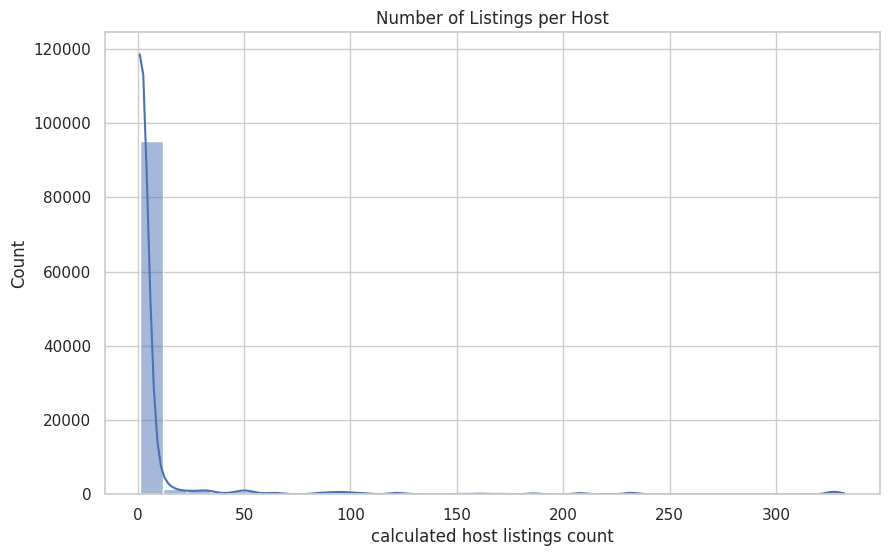

In [37]:
# Host Listings Count
sns.histplot(df['calculated host listings count'], bins=30, kde=True)
plt.title("Number of Listings per Host")
plt.show()

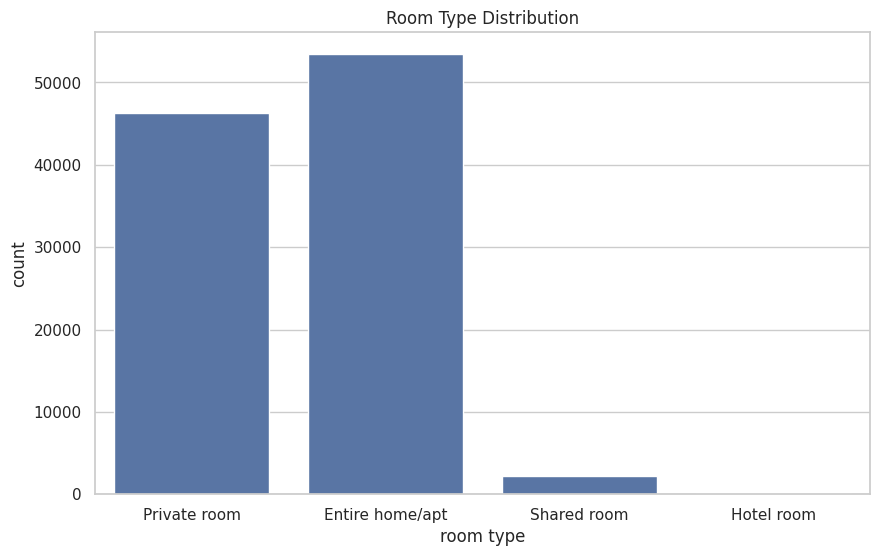

In [38]:
# -------- Room & Listing Analysis --------
# Room Type Distribution
sns.countplot(x='room type', data=df)
plt.title("Room Type Distribution")
plt.show()

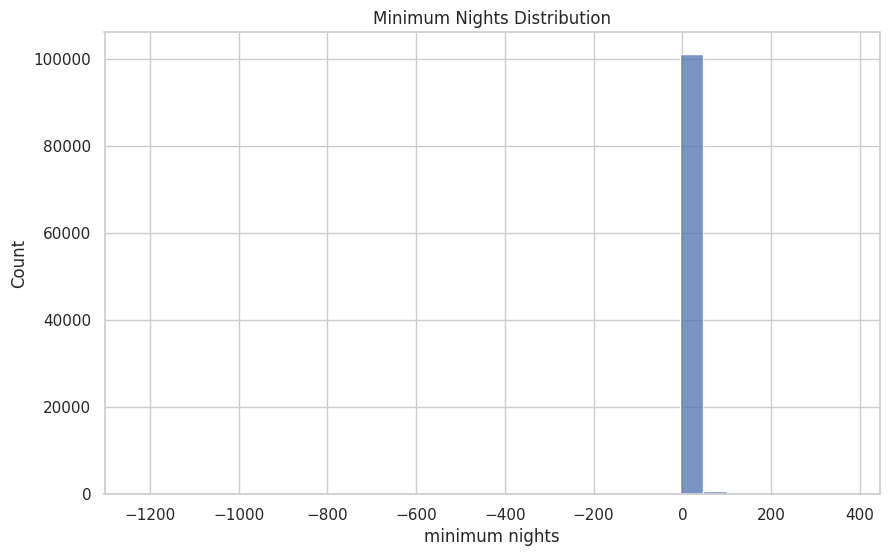

In [39]:
# Minimum Nights Distribution
sns.histplot(df['minimum nights'], bins=30)
plt.title("Minimum Nights Distribution")
plt.show()


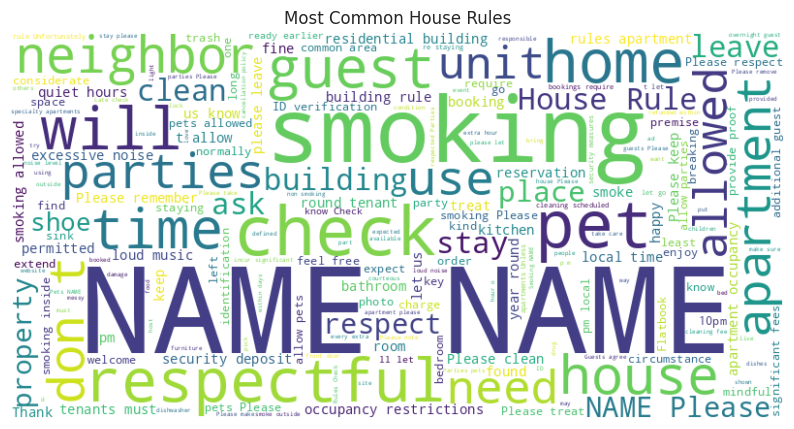

In [40]:
# House Rules WordCloud
all_rules = ' '.join(df['house_rules'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_rules)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common House Rules")
plt.show()

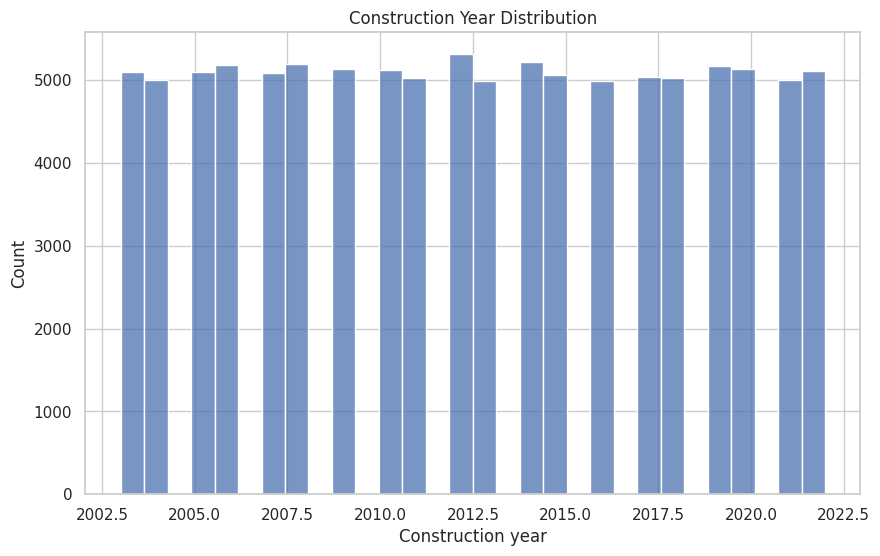

In [41]:
# Construction Year Analysis
sns.histplot(df['Construction year'], bins=30)
plt.title("Construction Year Distribution")
plt.show()

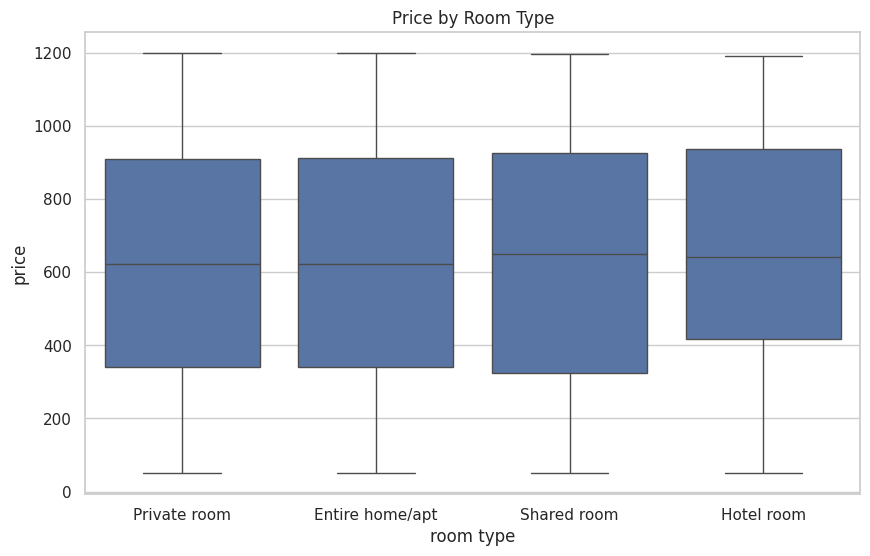

In [42]:
# Price vs Room Type
sns.boxplot(x='room type', y='price', data=df)
plt.title("Price by Room Type")
plt.show()

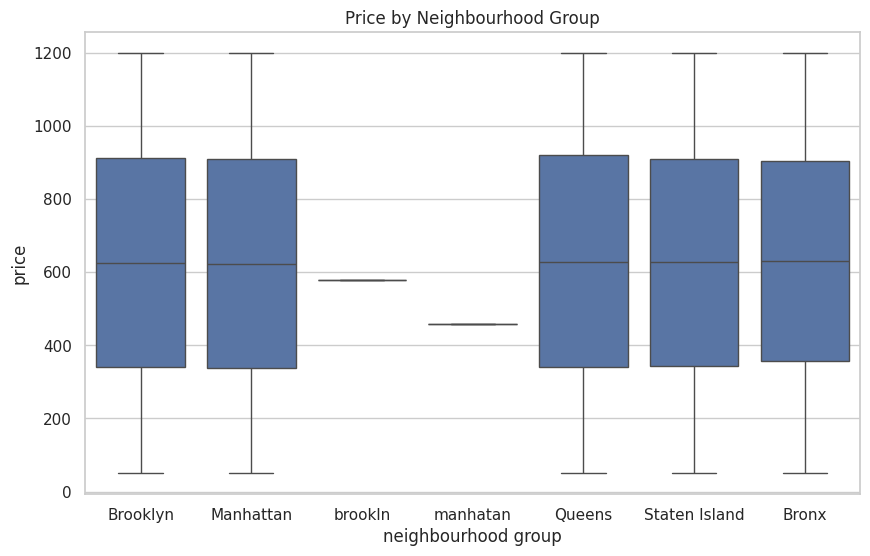

In [43]:
# Price vs Neighbourhood Group
sns.boxplot(x='neighbourhood group', y='price', data=df)
plt.title("Price by Neighbourhood Group")
plt.show()

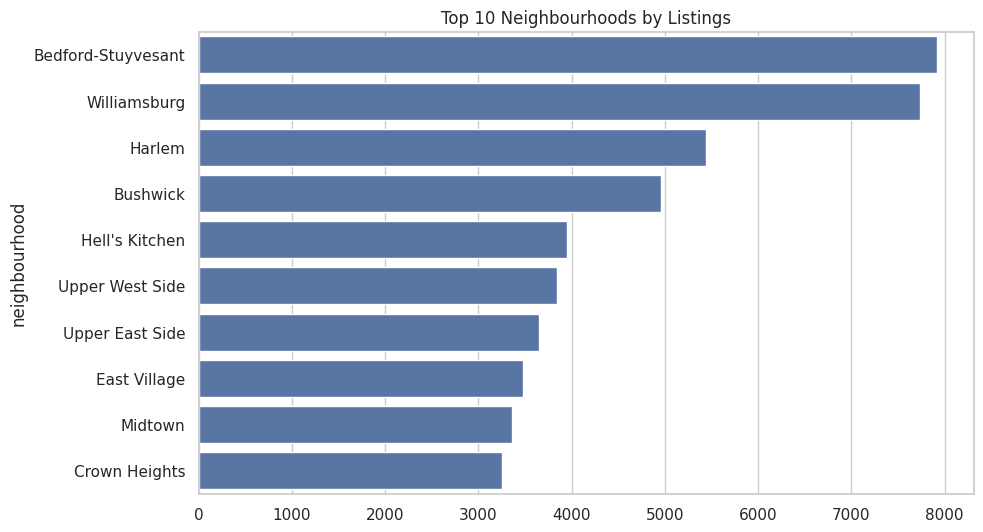

In [44]:
# -------- Geographic Analysis --------
# Popular Neighbourhoods
top_neigh = df['neighbourhood'].value_counts().head(10)
sns.barplot(x=top_neigh.values, y=top_neigh.index)
plt.title("Top 10 Neighbourhoods by Listings")
plt.show()

In [45]:
# Map of Listings (using Folium)
m = folium.Map(location=[df['lat'].mean(), df['long'].mean()], zoom_start=12)
for _, row in df.head(500).iterrows():  # limit for performance
    folium.CircleMarker(location=[row['lat'], row['long']],
                        radius=2, color='blue', fill=True).add_to(m)
m.save("airbnb_map.html")

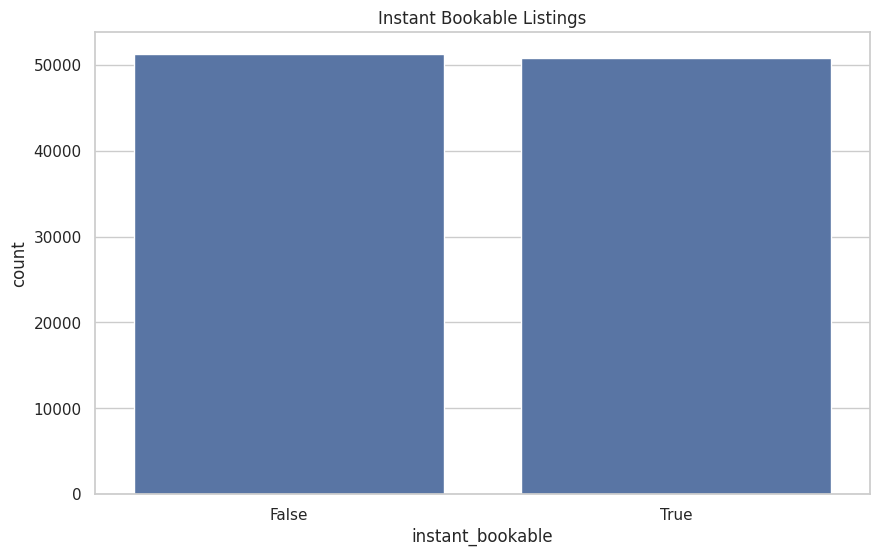

In [46]:
# -------- Booking & Availability --------
#Instant Bookable Listings
sns.countplot(x='instant_bookable', data=df)
plt.title("Instant Bookable Listings")
plt.show()

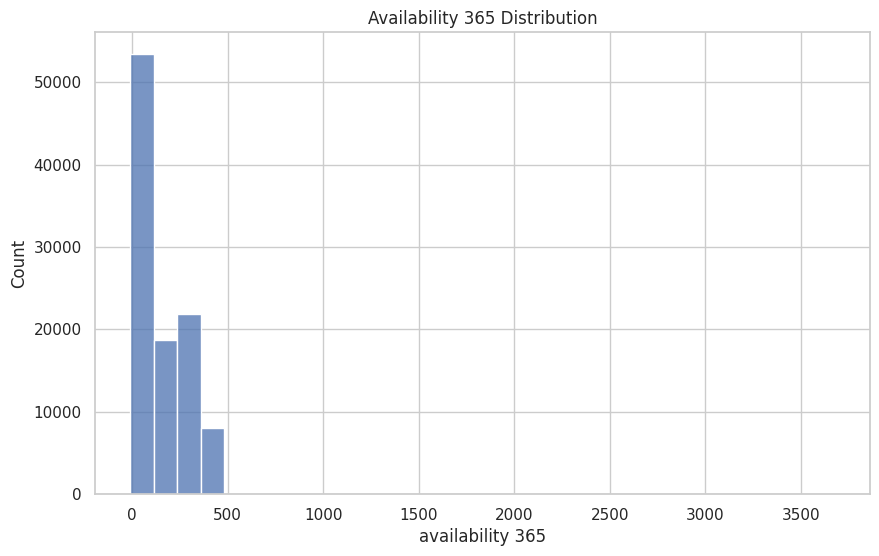

In [47]:
#Availability 365 Distribution
sns.histplot(df['availability 365'], bins=30)
plt.title("Availability 365 Distribution")
plt.show()

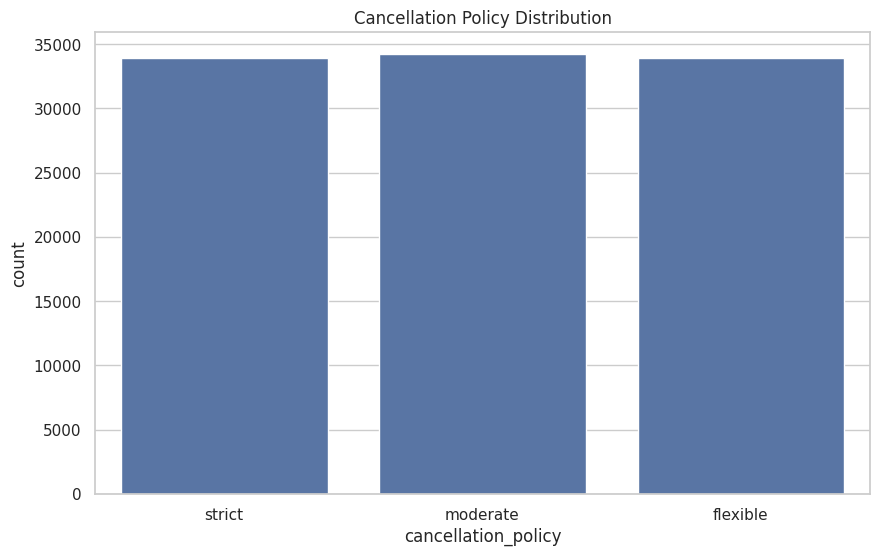

In [48]:
#Cancellation Policy Distribution
sns.countplot(x='cancellation_policy', data=df)
plt.title("Cancellation Policy Distribution")
plt.show()

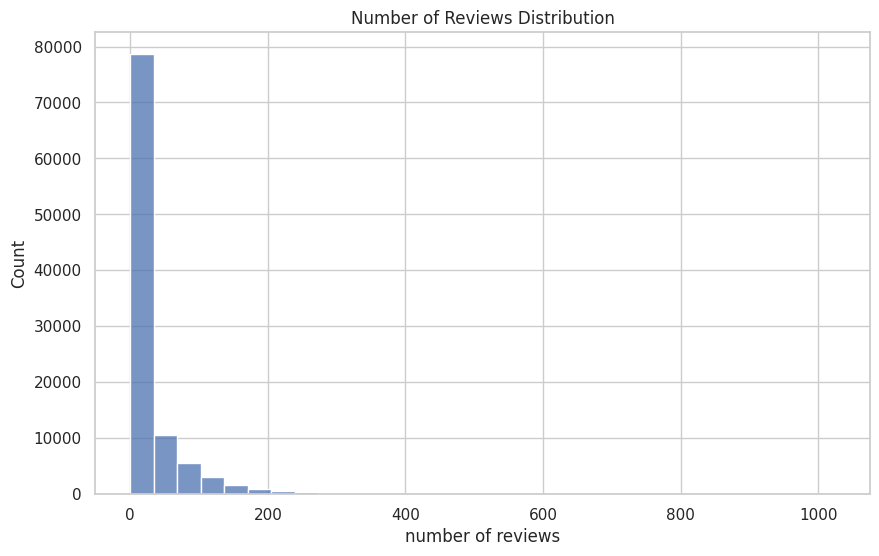

In [49]:
# -------- Reviews & Ratings --------
#Number of Reviews Distribution
sns.histplot(df['number of reviews'], bins=30)
plt.title("Number of Reviews Distribution")
plt.show()

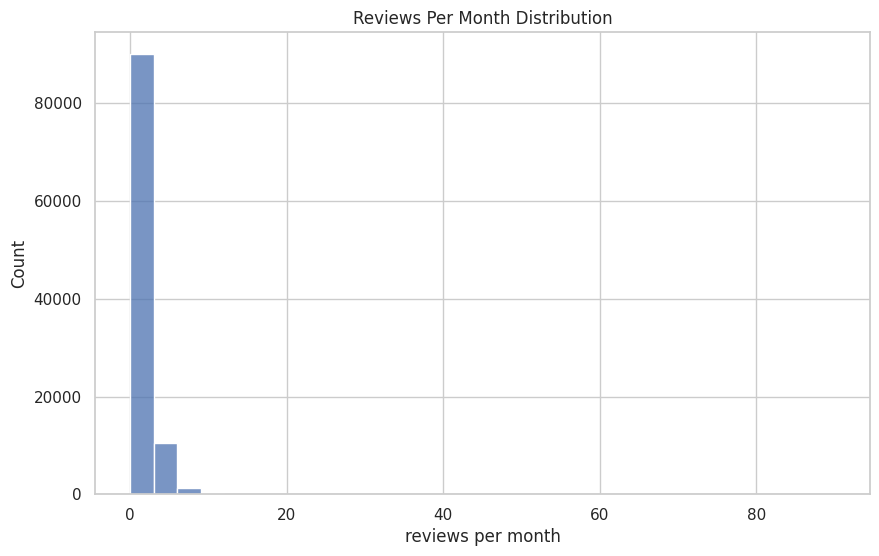

In [50]:
#Reviews Per Month Distribution
sns.histplot(df['reviews per month'], bins=30)
plt.title("Reviews Per Month Distribution")
plt.show()

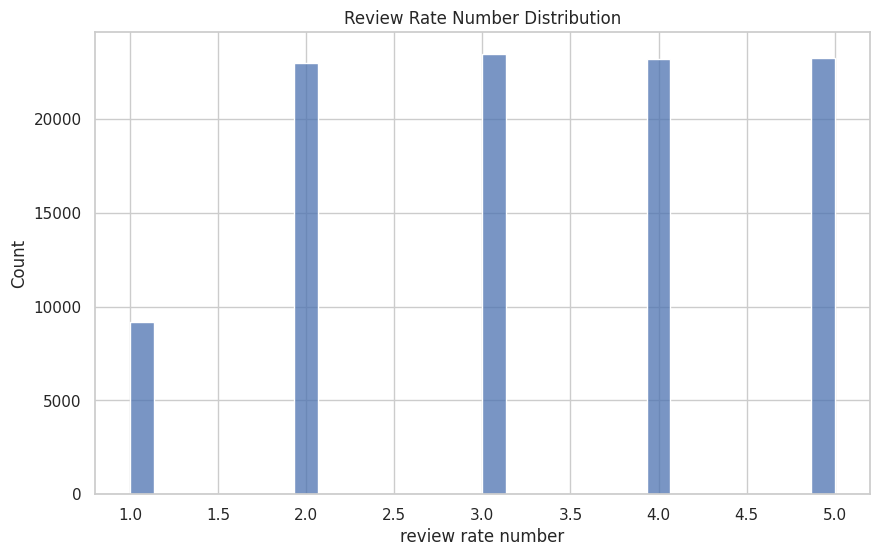

In [51]:
#Review Rate Number Distribution
sns.histplot(df['review rate number'], bins=30)
plt.title("Review Rate Number Distribution")
plt.show()

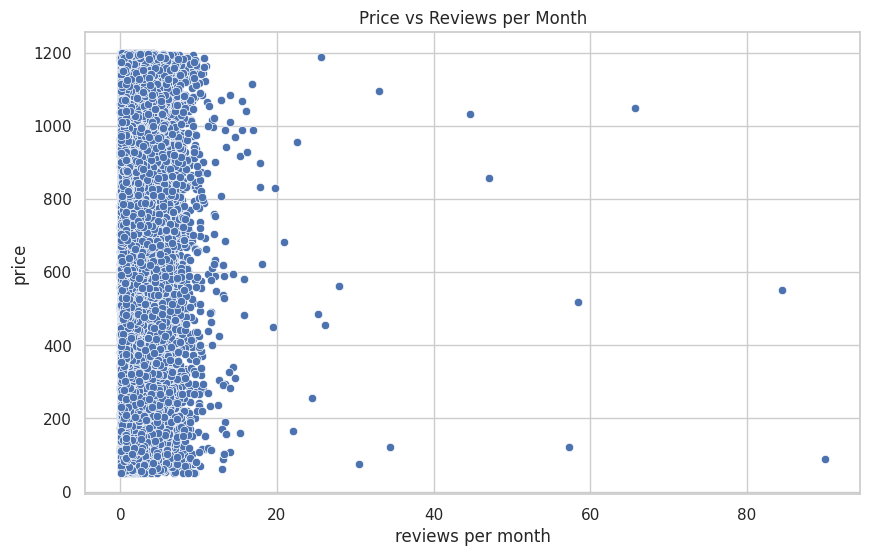

In [52]:
# Price vs Reviews Scatter
sns.scatterplot(x='reviews per month', y='price', data=df)
plt.title("Price vs Reviews per Month")
plt.show()

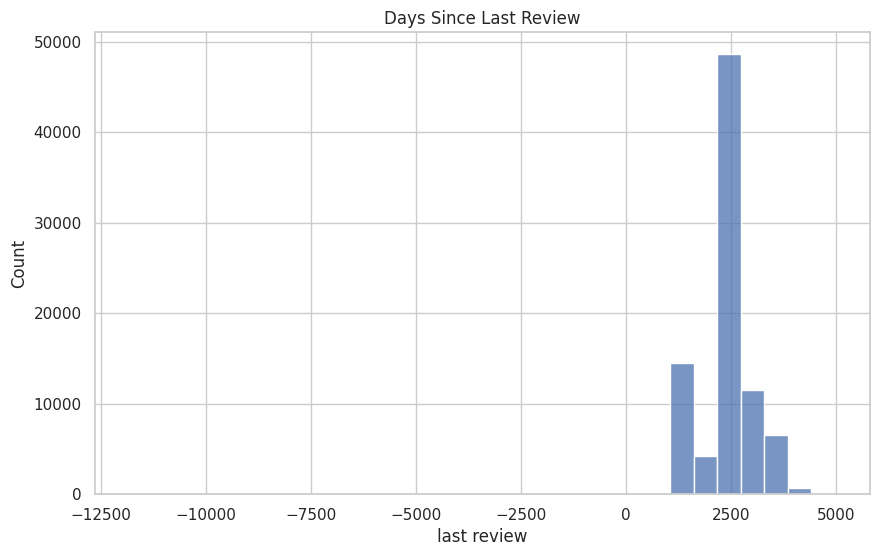

In [53]:
# Last Review Recency
recent_reviews = (datetime.datetime.now() - df['last review']).dt.days
sns.histplot(recent_reviews.dropna(), bins=30)
plt.title("Days Since Last Review")
plt.show()


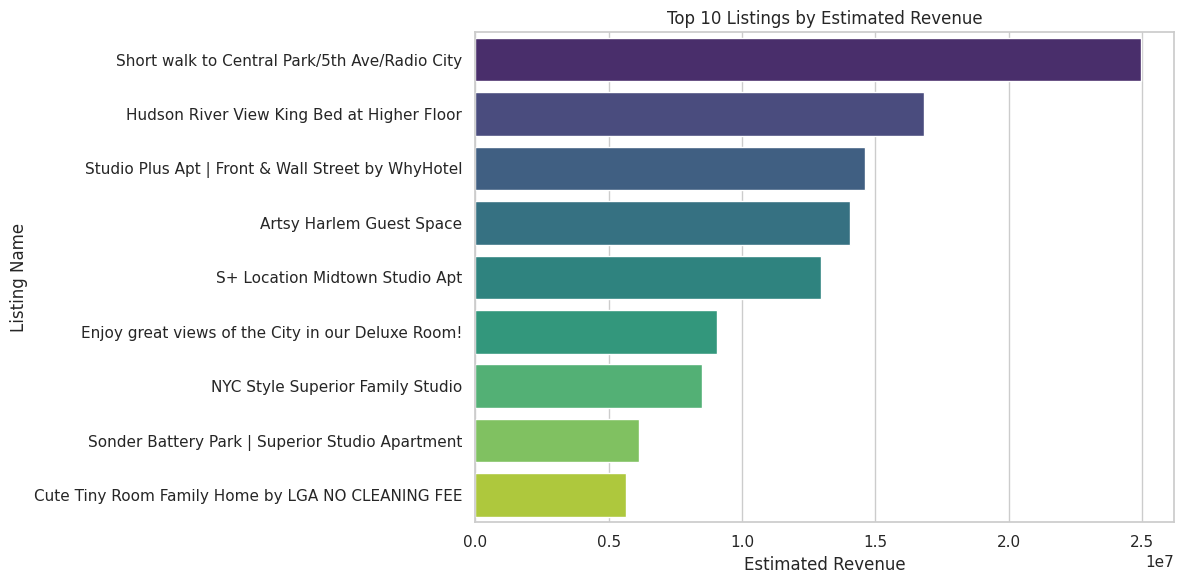

In [56]:
#Top 10 Listings by Estimated Revenue
df['estimated_revenue'] = df['price'] * df['availability 365'] * df['reviews per month'].fillna(0)
top_revenue = df[['NAME','estimated_revenue']].sort_values(by='estimated_revenue', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='estimated_revenue', y='NAME', data=top_revenue, palette='viridis')
plt.title('Top 10 Listings by Estimated Revenue')
plt.xlabel('Estimated Revenue')
plt.ylabel('Listing Name')
plt.tight_layout()
plt.show()

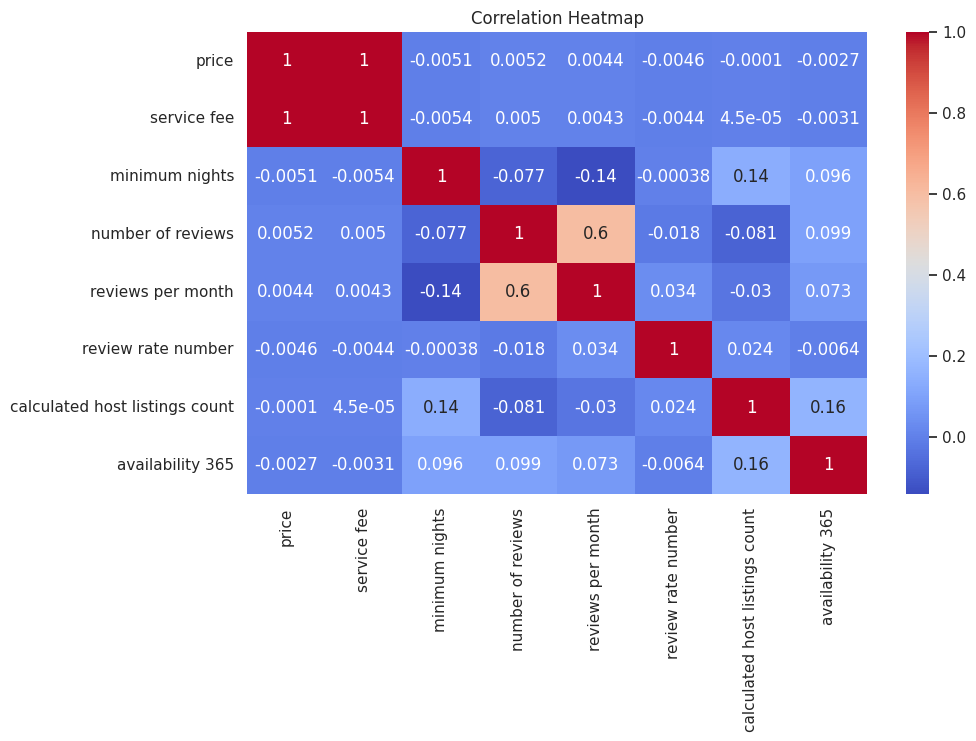

In [55]:
# Correlation Heatmap
corr = df[['price','service fee','minimum nights','number of reviews','reviews per month',
           'review rate number','calculated host listings count','availability 365']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()



#  Business Recommendations Based on Analysis

---

# 1 Pricing Strategy Recommendations

###  Insight:

* Entire homes are significantly more expensive than private/shared rooms.
* Some extreme price outliers exist.
* Price correlates moderately with review activity and location.

###  Recommendations:

### ✔ Optimize Pricing by Room Type

* **Entire homes** → Maintain premium pricing but justify with high-quality photos and amenities.
* **Private rooms** → Competitive pricing strategy to attract budget travelers.
* **Shared rooms** → Focus on affordability + high occupancy.

### ✔ Implement Dynamic Pricing

* Increase prices for:

  * High-demand neighborhoods
  * High-rated listings (4.5+ rating)
  * Instant-bookable properties

* Decrease prices for:

  * Listings with low reviews per month
  * Listings with high availability (low occupancy)

 Business Impact: Maximizes revenue while improving occupancy rate.

---

# 2️ Location-Based Recommendations

###  Insight:

* Certain neighbourhood groups dominate listing counts.
* Some areas show higher average prices.

###  Recommendations:

### ✔ Invest More in High-Demand Areas

* Focus marketing efforts in top 5 neighbourhoods.
* Encourage hosts in premium areas to upgrade listings.

### ✔ Improve Underperforming Areas

* Offer promotional discounts.
* Provide host training in pricing and customer experience.

 Business Impact: Balanced geographic growth and better market penetration.

---

# 3️ Host Performance Strategy

###  Insight:

* Verified hosts increase trust.
* Some hosts own multiple listings (power hosts).

###  Recommendations:

### ✔ Encourage Host Verification

* Add badge visibility for verified hosts.
* Offer ranking boost in search results.

### ✔ Manage High-Volume Hosts

* Identify “super hosts” with many listings.
* Provide premium partnership programs.

### ✔ Support New Hosts

* Training programs on:

  * Pricing optimization
  * Guest communication
  * Review improvement

 Business Impact: Improves platform trust and guest satisfaction.

---

# 4️ Reviews & Rating Optimization

###  Insight:

* Listings with more reviews per month likely generate more revenue.
* Review rate number impacts pricing power.

###  Recommendations:

### ✔ Improve Guest Experience

* Encourage quick responses to reviews.
* Offer automated follow-up messages after stay.

### ✔ Incentivize Reviews

* Provide small discount coupons for guests who leave reviews.

### ✔ Prioritize High-Rated Listings in Search

* Boost listings with 4.5+ rating.

 Business Impact: Higher trust → higher bookings → higher revenue.

---

# 5️ Availability & Occupancy Strategy

###  Insight:

* High availability (365 days available) may indicate low booking rate.
* Instant bookable listings may perform better.

###  Recommendations:

### ✔ Encourage Instant Booking

* Promote instant-bookable listings in search results.
* Offer fee discounts for enabling instant booking.

### ✔ Monitor Underperforming Listings

If:

* High availability
* Low reviews
* Low bookings

→ Suggest pricing adjustments automatically.

 Business Impact: Improves occupancy rate.

---

# 6️ Cancellation Policy Optimization

###  Insight:

* Some cancellation policies dominate.
* Flexible policies may attract more guests.

###  Recommendations:

### ✔ Promote Balanced Policy

* Encourage “moderate” cancellation policies.
* Analyze whether flexible policy increases bookings.

 Business Impact: Better guest confidence and conversion rate.

---

# 7️ Property Age Strategy (Construction Year)

###  Insight:

* Newer properties may justify higher prices.
* Older properties need value justification.

###  Recommendations:

### ✔ For New Properties

* Market as “modern” and “recently built”.

### ✔ For Older Properties

* Encourage renovation.
* Improve amenities to justify price.

 Business Impact: Higher perceived value.

---

# 8️ Revenue Optimization Strategy

###  Insight:

Estimated revenue depends on:

* Price
* Availability
* Reviews per month

###  Recommendations:

### ✔ Identify High Revenue Listings

* Create “Top Performing” category.
* Study characteristics of top 10 revenue listings.

### ✔ Replicate Success Patterns

If top listings share:

* Instant booking
* Entire home
* High rating
* Specific neighborhood

→ Encourage similar strategy platform-wide.

---

# 9️ Platform-Level Strategic Recommendations

###  Implement AI-Based Price Recommendation

Use:

* Room type
* Location
* Reviews
* Availability
* Host verification

To automatically recommend optimal pricing.

###  Build a Host Performance Dashboard

Include:

* Revenue estimate
* Occupancy rate
* Rating trends
* Price vs neighborhood average

###  Predictive Model

Develop:

* Price prediction model
* Booking likelihood model
* Revenue forecast model

 This makes your project **advanced Data Science level**.

---

#  Final Executive Summary

Based on the analysis:

1. Room type and location strongly influence price.
2. Reviews and ratings directly affect revenue potential.
3. Instant booking and verification improve trust.
4. Dynamic pricing and availability optimization can increase profitability.
5. High-performing listings share common success patterns.

---

